# 1. Data Preprocessing (Review & Extension)

 ## 1. Loading & Inspection:
  Load the data, display first 5 rows, check for missing values. Handle missing values in Income (median imputation).

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
df=pd.read_csv("data/marketing_campaign.csv",sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [160]:
df.isnull().sum()


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [161]:
df['Income'] = df['Income'].fillna(df['Income'].median())


In [162]:
df.isnull().sum().sum()

np.int64(0)

## 2. Feature Engineering:

* **Create Age from Year_Birth.**

In [163]:
df['Age'] = 2026 - df['Year_Birth']
df['Age'].head()

,Age
0,69
1,72
2,61
3,42
4,45


* **Create TotalSpending**

In [164]:
df['TotalSpending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['TotalSpending'].head()

,TotalSpending
0,1617
1,27
2,776
3,53
4,422


* **Create TotalChildren**

In [165]:
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']
df['TotalChildren'].head()

,TotalChildren
0,0
1,2
2,0
3,1
4,1


## 3. Filtering:
Remove unrealistic ages (<18 or >100) and zero-income rows.

In [166]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
print(df['Age'].max())
print(df['Age'].min())

86
30


In [167]:
df = df[(df['Income'] < 600000) & (df['Income'] > 0)]

I also removed extremely high income values as outliers to avoid distortion in model training.

## 4. Encoding:

* Label encode Education (e.g., "Basic"=0, "Graduation"=1, "Master"=2, "PhD"=3).


In [168]:
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [169]:
edu_map = {'Basic': 0, 'Graduation': 1, 'Master': 2, '2n Cycle': 2,'PhD': 3}
df['Education'] = df['Education'].map(edu_map)
df['Education'].unique()

array([1, 3, 2, 0])

* One-hot encode Marital_Status (keep top 4 categories, group others as "Other").

In [170]:
top4 = df['Marital_Status'].value_counts()
top4

,count
Marital_Status,
Married,864
Together,578
Single,479
Divorced,231
Widow,77
Alone,3
Absurd,2
YOLO,2


In [171]:
top4 = df['Marital_Status'].value_counts().head(4).index
for i in df.index:
    if df.loc[i, 'Marital_Status'] not in top4:
        df.loc[i, 'Marital_Status'] = 'Other'

df = pd.get_dummies(df, columns=['Marital_Status'], dtype=int)

df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,5524,1957,1,58138.0,0,0,04-09-2012,58,635,88,...,11,1,69,1617,0,0,0,0,1,0
1,2174,1954,1,46344.0,1,1,08-03-2014,38,11,1,...,11,0,72,27,2,0,0,0,1,0
2,4141,1965,1,71613.0,0,0,21-08-2013,26,426,49,...,11,0,61,776,0,0,0,0,0,1
3,6182,1984,1,26646.0,1,0,10-02-2014,26,11,4,...,11,0,42,53,1,0,0,0,0,1
4,5324,1981,3,58293.0,1,0,19-01-2014,94,173,43,...,11,0,45,422,1,0,1,0,0,0


In [172]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['year'] = df['Dt_Customer'].dt.year
df['month'] = df['Dt_Customer'].dt.month
df['day'] = df['Dt_Customer'].dt.day
df = df.drop(columns=['Dt_Customer'])

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2236 non-null   int64  
 1   Year_Birth               2236 non-null   int64  
 2   Education                2236 non-null   int64  
 3   Income                   2236 non-null   float64
 4   Kidhome                  2236 non-null   int64  
 5   Teenhome                 2236 non-null   int64  
 6   Recency                  2236 non-null   int64  
 7   MntWines                 2236 non-null   int64  
 8   MntFruits                2236 non-null   int64  
 9   MntMeatProducts          2236 non-null   int64  
 10  MntFishProducts          2236 non-null   int64  
 11  MntSweetProducts         2236 non-null   int64  
 12  MntGoldProds             2236 non-null   int64  
 13  NumDealsPurchases        2236 non-null   int64  
 14  NumWebPurchases          2236

# 2. Supervised Learning - Regression

In [174]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [175]:
X = df.drop([
    'TotalSpending',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'ID',
    'Year_Birth',
    'Z_CostContact',
    'Z_Revenue'
], axis=1)

y = df['TotalSpending']

## 1. Train/Test Split:
 80/20 split, random_state=42.

In [176]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

## 2. Feature Scaling:
Apply StandardScaler to numerical features (excluding target).

In [177]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Models to Implement

### 1. Linear Regression

In [178]:
LR_model = LinearRegression()
LR_model.fit(X_train_scaled, y_train)
LR_predictions = LR_model.predict(X_test_scaled)

In [179]:
LR_mse = mean_squared_error(y_test, LR_predictions)
LR_rmse = np.sqrt(LR_mse)
LR_r2 = r2_score(y_test, LR_predictions)

print("Linear Regression MSE:", round(LR_mse, 2))
print("Linear Regression RMSE:", round(LR_rmse, 2))
print("Linear Regression R2 Score:", round(LR_r2, 3))

Linear Regression MSE: 62256.06
Linear Regression RMSE: 249.51
Linear Regression R2 Score: 0.835


### 2. Ridge Regression (alpha=1.0)

In [180]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_predictions = ridge_model.predict(X_test_scaled)

In [181]:
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression MSE:", round(ridge_mse, 2))
print("Ridge Regression RMSE:", round(ridge_rmse, 2))
print("Ridge Regression R2 Score:", round(ridge_r2, 3))

Ridge Regression MSE: 62255.19
Ridge Regression RMSE: 249.51
Ridge Regression R2 Score: 0.835


### 3. Decision Tree Regressor (max_depth=5)

In [182]:
tree_model = DecisionTreeRegressor(max_depth=5,random_state=42)
tree_model.fit(X_train_scaled, y_train)
tree_predictions = tree_model.predict(X_test_scaled)

In [183]:
tree_mse = mean_squared_error(y_test, tree_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree MSE:", round(tree_mse, 2))
print("Decision Tree RMSE:", round(tree_rmse, 2))
print("Decision Tree R2 Score:", round(tree_r2, 3))

Decision Tree MSE: 85267.83
Decision Tree RMSE: 292.01
Decision Tree R2 Score: 0.774


## 4. Output:
 A comparison table of all three regression models showing their performance.

In [184]:
regression_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Decision Tree Regressor'
    ],
    'MSE': [
        LR_mse,
        ridge_mse,
        tree_mse
    ],
    'RMSE': [
        LR_rmse,
        ridge_rmse,
        tree_rmse
    ],
    'R2 Score': [
        LR_r2,
        ridge_r2,
        tree_r2
    ]
})

regression_results.round(3)

,Model,MSE,RMSE,R2 Score
0,Linear Regression,62256.063,249.512,0.835
1,Ridge Regression,62255.195,249.510,0.835
2,Decision Tree Regressor,85267.832,292.007,0.774


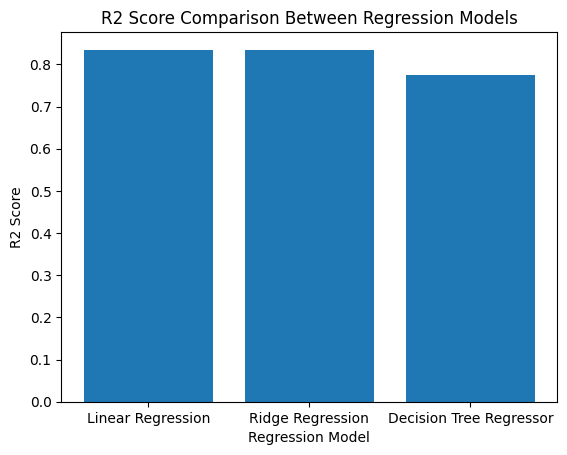

In [185]:
plt.bar(regression_results['Model'], regression_results['R2 Score'])

plt.title('R2 Score Comparison Between Regression Models')
plt.xlabel('Regression Model')
plt.ylabel('R2 Score')
plt.show()

Ridge Regression achieved the best performance because it has the lowest MSE and RMSE, while Linear Regression gave almost the same R2 score. Decision Tree Regressor performed slightly worse because it had higher error values.

# 3. Supervised Learning - Classification

In [186]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Note: Handle class imbalance (show class distribution first).

In [187]:
df['Response'].value_counts()

,count
Response,
0,1902
1,334


In [188]:
df['Response'].value_counts(normalize=True) * 100

,proportion
Response,
0,85.062612
1,14.937388


* **Select features and target**: drop the target column and identifiers from the dataframe.

In [189]:
X_clf = df.drop(columns=[
    'Response',
    'ID',
    'Dt_Customer',
    'Year_Birth',
    'Z_CostContact',
    'Z_Revenue'
], errors='ignore')

y_clf = df['Response']

* **Train and Test Split**: split the dataset into training and testing sets (80/20) with stratification to preserve class distribution.

In [190]:
from sklearn.model_selection import train_test_split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print('Training data:', X_train_clf.shape)
print('Testing data:', X_test_clf.shape)

Training data: (1788, 33)
Testing data: (448, 33)


## 2. Feature Scaling and Oversampling

Standardize the feature variables using StandardScaler so that models are not affected by different scales.
After scaling, apply **SMOTE** to the training set to oversample the minority class and balance the dataset.
The test set is left unchanged to ensure a realistic evaluation.

In [191]:
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_scaled = scaler_clf.transform(X_test_clf)

# Oversample the training data using SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_os, y_train_os = smote.fit_resample(X_train_scaled, y_train_clf)

print('Class distribution before SMOTE:', y_train_clf.value_counts().to_dict())
print('Class distribution after SMOTE:', pd.Series(y_train_os).value_counts().to_dict())

Class distribution before SMOTE: {0: 1521, 1: 267}
Class distribution after SMOTE: {1: 1521, 0: 1521}


## 3. Models to Implement

### 1. Logistic Regression

In [192]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_os, y_train_os)

log_preds = log_model.predict(X_test_scaled)

In [193]:
# Evaluation metrics for Logistic Regression
log_acc = accuracy_score(y_test_clf, log_preds)
log_bal_acc = balanced_accuracy_score(y_test_clf, log_preds)
log_prec = precision_score(y_test_clf, log_preds, zero_division=0)
log_rec = recall_score(y_test_clf, log_preds, zero_division=0)
log_f1 = f1_score(y_test_clf, log_preds, zero_division=0)

print('Logistic Regression Accuracy:', round(log_acc, 3))
print('Logistic Regression Balanced Accuracy:', round(log_bal_acc, 3))
print('Logistic Regression Precision:', round(log_prec, 3))
print('Logistic Regression Recall:', round(log_rec, 3))
print('Logistic Regression F1 Score:', round(log_f1, 3))

Logistic Regression Accuracy: 0.81
Logistic Regression Balanced Accuracy: 0.778
Logistic Regression Precision: 0.422
Logistic Regression Recall: 0.731
Logistic Regression F1 Score: 0.536


In [194]:
print(classification_report(y_test_clf, log_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.82      0.88       381
           1       0.42      0.73      0.54        67

    accuracy                           0.81       448
   macro avg       0.68      0.78      0.71       448
weighted avg       0.87      0.81      0.83       448



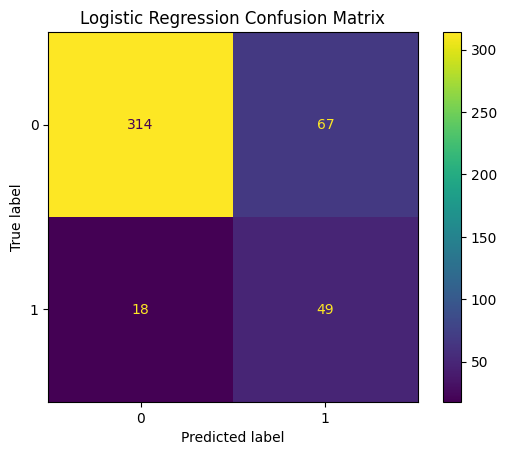

In [195]:
log_cm = confusion_matrix(y_test_clf, log_preds)
ConfusionMatrixDisplay(log_cm).plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### 2. K-Nearest Neighbors

In [196]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_os, y_train_os)

knn_preds = knn_model.predict(X_test_scaled)

In [197]:
# Evaluation metrics for KNN
knn_acc = accuracy_score(y_test_clf, knn_preds)
knn_bal_acc = balanced_accuracy_score(y_test_clf, knn_preds)
knn_prec = precision_score(y_test_clf, knn_preds, zero_division=0)
knn_rec = recall_score(y_test_clf, knn_preds, zero_division=0)
knn_f1 = f1_score(y_test_clf, knn_preds, zero_division=0)

print('KNN Accuracy:', round(knn_acc, 3))
print('KNN Balanced Accuracy:', round(knn_bal_acc, 3))
print('KNN Precision:', round(knn_prec, 3))
print('KNN Recall:', round(knn_rec, 3))
print('KNN F1 Score:', round(knn_f1, 3))

KNN Accuracy: 0.737
KNN Balanced Accuracy: 0.71
KNN Precision: 0.319
KNN Recall: 0.672
KNN F1 Score: 0.433


In [198]:
print(classification_report(y_test_clf, knn_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83       381
           1       0.32      0.67      0.43        67

    accuracy                           0.74       448
   macro avg       0.62      0.71      0.63       448
weighted avg       0.84      0.74      0.77       448



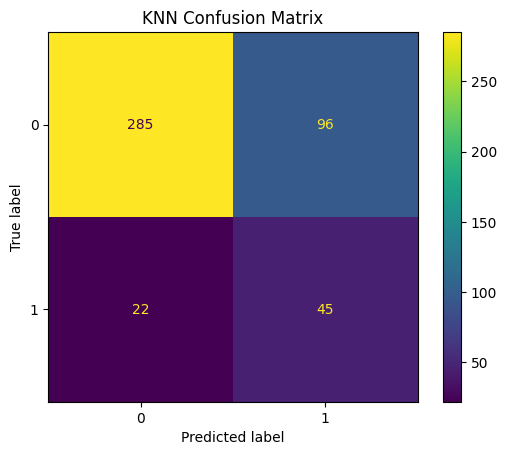

In [199]:
knn_cm = confusion_matrix(y_test_clf, knn_preds)
ConfusionMatrixDisplay(knn_cm).plot()
plt.title('KNN Confusion Matrix')
plt.show()

### 3. Random Forest Classifier

In [200]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_os, y_train_os)

rf_preds = rf_model.predict(X_test_scaled)

In [201]:
# Evaluation metrics for Random Forest
rf_acc = accuracy_score(y_test_clf, rf_preds)
rf_bal_acc = balanced_accuracy_score(y_test_clf, rf_preds)
rf_prec = precision_score(y_test_clf, rf_preds, zero_division=0)
rf_rec = recall_score(y_test_clf, rf_preds, zero_division=0)
rf_f1 = f1_score(y_test_clf, rf_preds, zero_division=0)

print('Random Forest Accuracy:', round(rf_acc, 3))
print('Random Forest Balanced Accuracy:', round(rf_bal_acc, 3))
print('Random Forest Precision:', round(rf_prec, 3))
print('Random Forest Recall:', round(rf_rec, 3))
print('Random Forest F1 Score:', round(rf_f1, 3))

Random Forest Accuracy: 0.884
Random Forest Balanced Accuracy: 0.735
Random Forest Precision: 0.636
Random Forest Recall: 0.522
Random Forest F1 Score: 0.574


In [202]:
print(classification_report(y_test_clf, rf_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       381
           1       0.64      0.52      0.57        67

    accuracy                           0.88       448
   macro avg       0.78      0.73      0.75       448
weighted avg       0.88      0.88      0.88       448



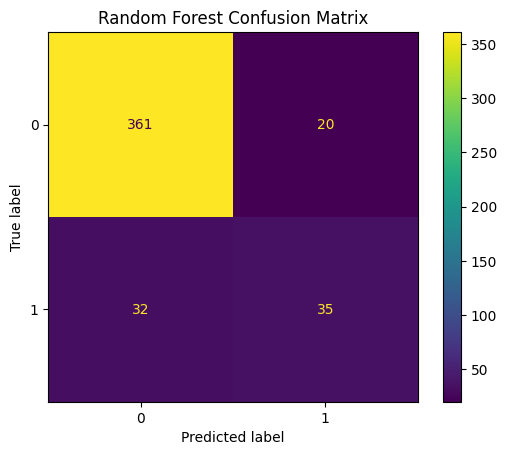

In [203]:
rf_cm = confusion_matrix(y_test_clf, rf_preds)
ConfusionMatrixDisplay(rf_cm).plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

## Output: Classification metrics and confusion matrices

After applying SMOTE, we evaluate each classifier using accuracy, balanced accuracy, precision, recall and F1 score. Balanced accuracy and F1 score are more informative metrics for imbalanced datasets because they consider performance on both classes. The confusion matrices visualize the true/false positives and negatives for each model.

In [204]:
# Compare classifiers
results_clf = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        log_acc,
        knn_acc,
        rf_acc
    ],
    'Balanced Accuracy': [
        log_bal_acc,
        knn_bal_acc,
        rf_bal_acc
    ],
    'Precision': [
        log_prec,
        knn_prec,
        rf_prec
    ],
    'Recall': [
        log_rec,
        knn_rec,
        rf_rec
    ],
    'F1 Score': [
        log_f1,
        knn_f1,
        rf_f1
    ]
})

results_clf = results_clf.sort_values(by='F1 Score', ascending=False)
results_clf.round(3)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.884,0.735,0.636,0.522,0.574
0,Logistic Regression,0.810,0.778,0.422,0.731,0.536
1,KNN,0.737,0.710,0.319,0.672,0.433


# 4. Unsupervised Learning - Clustering

## 1. Data Preparation:
Select the 4 features above, scale them using StandardScaler.

In [205]:
cluster_data = df[['Income', 'TotalSpending', 'Age', 'TotalChildren']]

# Selecting clustering features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)


## 2. K-Means Clustering

### 1. Use the Elbow Method (inertia vs. k from 1 to 10) to determine optimal k.

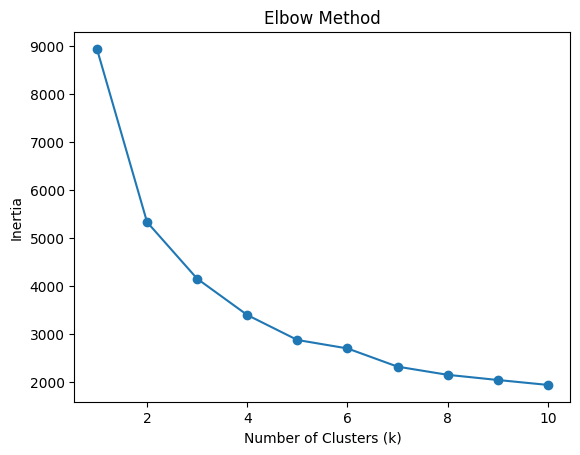

In [206]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

Based on the Elbow Method, k = 4 was selected because the decrease in inertia starts to slow down after this point.

### 2. Fit K-Means with the chosen k (random_state=42).

In [207]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(cluster_scaled)

df['Cluster'] = clusters

## 3. Visualization: Create a 2D scatter plot (using PCA reduction to 2 components) colored by cluster label.

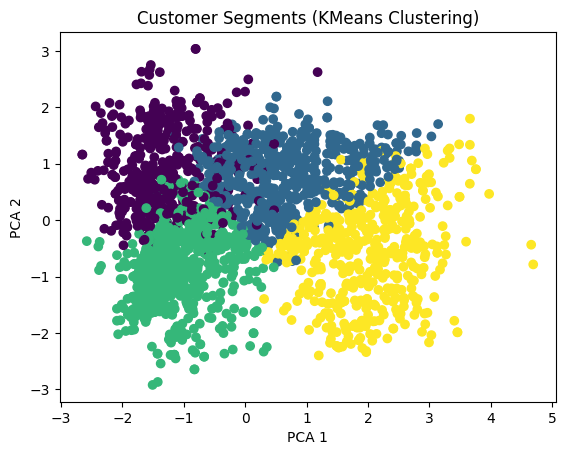

In [208]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_scaled)

plt.scatter(pca_result[:, 0], pca_result[:, 1], c=clusters, cmap='viridis')
plt.title("Customer Segments (KMeans Clustering)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Based on the Elbow Method, k = 4 was selected because the decrease in inertia starts to slow down after this point.

## 4. Cluster Profiling:
For each cluster, compute mean values of Income, TotalSpending, Age, TotalChildren. Briefly describe each customer segment (e.g., "High-income, high-spending young singles").

In [209]:
cluster_summary = df.groupby('Cluster')[['Income', 'TotalSpending', 'Age', 'TotalChildren']].mean()
cluster_summary

,Income,TotalSpending,Age,TotalChildren
Cluster,,,,
0,43884.015521,215.172949,60.616408,2.117517
1,61037.173989,772.655536,68.340949,0.757469
2,32802.090220,153.742424,49.066116,0.841598
3,77203.845918,1442.214286,52.722449,0.263265


* Cluster 0: Medium-low income, low spending customers with the highest number of children.
* Cluster 1: Medium-high income, high spending, older customers with fewer children.
* Cluster 2: Lowest income and lowest spending customers, middle-aged with relatively few children.
* Cluster 3: Highest income and highest spending customers, with very few children.